In [1]:
#regex tutorial
import re
import pandas as pd
from wordcloud import WordCloud
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob
import plotly.express as px
from nltk.corpus import stopwords

In [2]:
import nltk
from nltk.stem import WordNetLemmatizer

In [10]:
#dataframes
df1=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-28-24-893.csv")
df2=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-24-32-571.csv")
df3=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-22-11-576.csv")
df4=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-06-14-505.csv")
df5=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-04-00-751.csv")
df6=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_14-01-16-477.csv")
df7=pd.read_csv("C:/Users/SWRM/Downloads/dataset_google-maps-reviews-scraper-task_2025-09-21_13-53-10-475.csv")
df8=pd.read_csv("C:/Users/SWRM/Downloads/dataset_Google-Maps-Reviews-Scraper_2025-09-28_01-45-37-160.csv")


In [11]:
#getting title of all dataframes
print(f"Title for dataframe 1 is {df1.title.unique()}")
print(f"Title for dataframe 2 is {df2.title.unique()}")
print(f"Title for dataframe 3 is {df3.title.unique()}")
print(f"Title for dataframe 4 is {df4.title.unique()}")
print(f"Title for dataframe 5 is {df5.title.unique()}")
print(f"Title for dataframe 6 is {df6.title.unique()}")
print(f"Title for dataframe 7 is {df7.title.unique()}")
print(f"Title for dataframe 7 is {df8.title.unique()}")

Title for dataframe 1 is ['Darwin Military Museum']
Title for dataframe 2 is ['Darwin Aviation Museum']
Title for dataframe 3 is ['RFDS Darwin Tourist Facility']
Title for dataframe 4 is ['Darwin Aviation Museum']
Title for dataframe 5 is ['Museum and Art Gallery of the Northern Territory']
Title for dataframe 6 is ['RFDS Darwin Tourist Facility']
Title for dataframe 7 is ['Darwin Military Museum']
Title for dataframe 7 is ['Museum and Art Gallery of the Northern Territory']


In [12]:
#I will join dataframes with the same title, remove duplicates, then create one big dataframe comprising of all the dataframes
military_df=pd.concat([df1,df7])
aviation_df=pd.concat([df2,df4])
rfds_df=pd.concat([df3,df6])
art_df=pd.concat([df5,df8])

In [13]:
print(f"Military df duplicate count :{military_df.duplicated().sum()}")
print(f"Aviation df duplicate count :{aviation_df.duplicated().sum()}")
print(f"RFDS df duplicate count :{rfds_df.duplicated().sum()}")
print(f"Art gallery df duplicate count :{art_df.duplicated().sum()}")

Military df duplicate count :0
Aviation df duplicate count :0
RFDS df duplicate count :0
Art gallery df duplicate count :1


In [14]:
art_df.drop_duplicates(inplace=True)

In [15]:
#checking for null values
def null_checker(dataframe,df_name):
    '''
    Function will read in dataframe and return a list of all the columns with over 50 null values
    Which will later on be removed from the corresponding dataset
    
    '''
    
    null_df=dataframe.isnull().sum().to_frame()
    df_len=len(dataframe)
    print(df_len)
    null_df["null_percentage"]=(null_df[0]/df_len)*100
    null_df=null_df.loc[null_df["null_percentage"]>=50]
    dataframe=dataframe.drop(null_df.index,axis=1)
    return dataframe


In [16]:
military_df=null_checker(military_df,"military_df")
aviation_df=null_checker(aviation_df,"military_df")
rfds_df=null_checker(rfds_df,"military_df")
art_df=null_checker(art_df,"military_df")

109
126
112
278


In [17]:
art_df.isnull().sum()

address                                    0
categories/0                               0
categories/1                               0
categories/2                               0
categories/3                               0
categories/4                               0
categories/5                               0
categories/6                               0
categories/7                               0
categories/8                               0
categories/9                               0
categoryName                               0
cid                                        0
city                                       0
countryCode                                0
fid                                        0
imageUrl                                   0
isAdvertisement                            0
isLocalGuide                               0
language                                   0
likesCount                                 0
location/lat                               0
location/l

In [18]:
#removing unneccesary columns
military_df.columns

Index(['address', 'categories/0', 'categories/1', 'categories/2',
       'categories/3', 'categoryName', 'cid', 'city', 'countryCode', 'fid',
       'imageUrl', 'isAdvertisement', 'isLocalGuide', 'language', 'likesCount',
       'location/lat', 'location/lng', 'originalLanguage', 'permanentlyClosed',
       'placeId', 'postalCode', 'publishAt', 'publishedAtDate',
       'reviewContext/Reservation recommended', 'reviewContext/Visited on',
       'reviewContext/Wait time', 'reviewImageUrls/0', 'reviewImageUrls/1',
       'reviewImageUrls/2', 'reviewImageUrls/3', 'reviewImageUrls/4',
       'reviewOrigin', 'reviewerNumberOfReviews', 'reviewsCount', 'scrapedAt',
       'searchString', 'stars', 'state', 'street', 'temporarilyClosed', 'text',
       'title', 'totalScore', 'url'],
      dtype='object')

In [19]:
columns_to_drop_military_df=['address','cid', 'city', 'countryCode', 'fid',
       'imageUrl','location/lat', 'location/lng','originalLanguage', 'permanentlyClosed',
       'placeId', 'postalCode','reviewImageUrls/0', 'reviewImageUrls/1',
       'reviewImageUrls/2', 'reviewImageUrls/3', 'reviewImageUrls/4','reviewOrigin','scrapedAt','searchString','street','url']
military_df.drop(columns_to_drop_military_df,axis=1,inplace=True)

In [20]:
military_df.columns

Index(['categories/0', 'categories/1', 'categories/2', 'categories/3',
       'categoryName', 'isAdvertisement', 'isLocalGuide', 'language',
       'likesCount', 'publishAt', 'publishedAtDate',
       'reviewContext/Reservation recommended', 'reviewContext/Visited on',
       'reviewContext/Wait time', 'reviewerNumberOfReviews', 'reviewsCount',
       'stars', 'state', 'temporarilyClosed', 'text', 'title', 'totalScore'],
      dtype='object')

In [21]:
columns_to_drop_aviation=['address','cid', 'city', 'countryCode', 'fid',
       'imageUrl','location/lat', 'location/lng','originalLanguage', 'permanentlyClosed',
       'placeId', 'postalCode','reviewImageUrls/0', 'reviewImageUrls/1',
       'reviewImageUrls/2', 'reviewImageUrls/3','reviewOrigin','scrapedAt','searchString','street','url']
aviation_df.drop(columns_to_drop_aviation,axis=1,inplace=True)

In [22]:
columns_to_drop_rfds=['address','cid', 'city', 'countryCode', 'fid',
       'imageUrl','location/lat', 'location/lng','originalLanguage', 'permanentlyClosed',
       'placeId', 'postalCode','reviewImageUrls/0','reviewOrigin','scrapedAt','searchString','street','url']
rfds_df.drop(columns_to_drop_rfds,axis=1,inplace=True)

In [23]:
art_df.drop(['address','cid', 'city', 'countryCode', 'fid',
       'imageUrl','location/lat', 'location/lng','originalLanguage', 'permanentlyClosed',
       'placeId', 'postalCode','reviewOrigin','scrapedAt','searchString','street','url'],axis=1,inplace=True)

In [24]:
#cc=pd.concat([military_df,df5],axis=0)

In [25]:
#dealing with remaining null values
military_df.isnull().sum()

categories/0                              0
categories/1                              0
categories/2                              0
categories/3                              0
categoryName                              0
isAdvertisement                           0
isLocalGuide                              0
language                                  0
likesCount                                0
publishAt                                 0
publishedAtDate                           0
reviewContext/Reservation recommended    50
reviewContext/Visited on                 43
reviewContext/Wait time                  46
reviewerNumberOfReviews                   0
reviewsCount                              0
stars                                     0
state                                     0
temporarilyClosed                         0
text                                      3
title                                     0
totalScore                                0
dtype: int64

In [26]:
military_df['reviewContext/Wait time'].fillna(military_df['reviewContext/Wait time'].mode().values[0],inplace=True)
military_df['reviewContext/Reservation recommended'].fillna(military_df['reviewContext/Reservation recommended'].mode().values[0],inplace=True)
military_df['reviewContext/Visited on'].fillna(military_df['reviewContext/Visited on'].mode().values[0],inplace=True)

In [27]:
military_df.dropna(inplace=True)
military_df.isnull().sum()

categories/0                             0
categories/1                             0
categories/2                             0
categories/3                             0
categoryName                             0
isAdvertisement                          0
isLocalGuide                             0
language                                 0
likesCount                               0
publishAt                                0
publishedAtDate                          0
reviewContext/Reservation recommended    0
reviewContext/Visited on                 0
reviewContext/Wait time                  0
reviewerNumberOfReviews                  0
reviewsCount                             0
stars                                    0
state                                    0
temporarilyClosed                        0
text                                     0
title                                    0
totalScore                               0
dtype: int64

In [28]:
aviation_df['reviewContext/Wait time'].fillna(aviation_df['reviewContext/Wait time'].mode().values[0],inplace=True)
aviation_df['reviewContext/Reservation recommended'].fillna(aviation_df['reviewContext/Reservation recommended'].mode().values[0],inplace=True)
aviation_df['reviewContext/Visited on'].fillna(aviation_df['reviewContext/Visited on'].mode().values[0],inplace=True)

In [29]:
aviation_df.dropna(inplace=True)
aviation_df.isnull().sum()

categories/0                             0
categories/1                             0
categories/2                             0
categories/3                             0
categories/4                             0
categoryName                             0
isAdvertisement                          0
isLocalGuide                             0
language                                 0
likesCount                               0
publishAt                                0
publishedAtDate                          0
reviewContext/Reservation recommended    0
reviewContext/Visited on                 0
reviewContext/Wait time                  0
reviewerNumberOfReviews                  0
reviewsCount                             0
stars                                    0
state                                    0
temporarilyClosed                        0
text                                     0
title                                    0
totalScore                               0
dtype: int6

In [30]:
rfds_df.isnull().sum()

categories/0                              0
categories/1                              0
categories/2                              0
categories/3                              0
categoryName                              0
isAdvertisement                           0
isLocalGuide                              0
language                                  0
likesCount                                0
publishAt                                 0
publishedAtDate                           0
responseFromOwnerDate                     7
responseFromOwnerText                     7
reviewContext/Reservation recommended    50
reviewContext/Visited on                 44
reviewContext/Wait time                  45
reviewerNumberOfReviews                   0
reviewsCount                              0
stars                                     0
state                                     0
temporarilyClosed                         0
text                                      6
title                           

In [31]:
rfds_df['reviewContext/Wait time'].fillna(rfds_df['reviewContext/Wait time'].mode().values[0],inplace=True)
rfds_df['reviewContext/Reservation recommended'].fillna(rfds_df['reviewContext/Reservation recommended'].mode().values[0],inplace=True)
rfds_df['reviewContext/Visited on'].fillna(rfds_df['reviewContext/Visited on'].mode().values[0],inplace=True)

In [32]:
rfds_df.dropna(inplace=True)
rfds_df.isnull().sum()

categories/0                             0
categories/1                             0
categories/2                             0
categories/3                             0
categoryName                             0
isAdvertisement                          0
isLocalGuide                             0
language                                 0
likesCount                               0
publishAt                                0
publishedAtDate                          0
responseFromOwnerDate                    0
responseFromOwnerText                    0
reviewContext/Reservation recommended    0
reviewContext/Visited on                 0
reviewContext/Wait time                  0
reviewerNumberOfReviews                  0
reviewsCount                             0
stars                                    0
state                                    0
temporarilyClosed                        0
text                                     0
title                                    0
totalScore 

In [33]:
art_df['reviewContext/Wait time'].fillna("None",inplace=True)
art_df['reviewContext/Reservation recommended'].fillna("None",inplace=True)
art_df['reviewContext/Visited on'].fillna("None",inplace=True)

In [34]:
art_df.dropna(inplace=True)
art_df.isnull().sum()

categories/0                             0
categories/1                             0
categories/2                             0
categories/3                             0
categories/4                             0
categories/5                             0
categories/6                             0
categories/7                             0
categories/8                             0
categories/9                             0
categoryName                             0
isAdvertisement                          0
isLocalGuide                             0
language                                 0
likesCount                               0
publishAt                                0
publishedAtDate                          0
reviewContext/Reservation recommended    0
reviewContext/Visited on                 0
reviewContext/Wait time                  0
reviewImageUrls/0                        0
reviewImageUrls/1                        0
reviewerNumberOfReviews                  0
reviewsCoun

In [35]:
art_df.drop(["reviewImageUrls/0","reviewImageUrls/1"],axis=1,inplace=True)

In [36]:
#concating all the data
military_aviation=pd.concat([military_df,aviation_df])
rfds_df5=pd.concat([rfds_df,art_df])
df=pd.concat([military_aviation,rfds_df5])

In [37]:
df.fillna("None",inplace=True)

In [38]:
df.isnull().sum()

categories/0                             0
categories/1                             0
categories/2                             0
categories/3                             0
categoryName                             0
isAdvertisement                          0
isLocalGuide                             0
language                                 0
likesCount                               0
publishAt                                0
publishedAtDate                          0
reviewContext/Reservation recommended    0
reviewContext/Visited on                 0
reviewContext/Wait time                  0
reviewerNumberOfReviews                  0
reviewsCount                             0
stars                                    0
state                                    0
temporarilyClosed                        0
text                                     0
title                                    0
totalScore                               0
categories/4                             0
responseFro

## First, we will run the dataframe through Textblob and return sentiment column

In [39]:
def classify_emotion(review):
    analysis = TextBlob(review)
    if analysis.sentiment.polarity >0:
        return 'Positive' 
    elif analysis.sentiment.polarity <0:
        return 'Negative'       
    else:
        return 'Neutral'

In [40]:
sentiment_list=[]
translation_dictionary={
    'Entrada gratuita y se agradece mucho, me encantó conocer más sobre la cultura Tiwi, las instalaciones son bellas y el personal amable':'Admission is free, and donations are much appreciated. I loved learning more about the Tiwi culture. The facilities are beautiful and the staff is friendly.',
    'Spændende sted, med både kunst, natur, skibsfart og en særlig spændende udstilling om den orkan der ramte Darwin i 1974. Og så er det gratis at komme ind':'An exciting place, with art, nature, shipping, and a particularly interesting exhibition about the hurricane that hit Darwin in 1974. And admission is free',
    "Zeer educatief en mooi', 'Nor open": 'Very educational and beautiful. Not open',
    "Un museo che mostra( finalmente) arte aborigena. Per chi ama poi la storia, si può rivivere il terribile uragano che distrusse quasi completamente la città con delle mappe per quartiere che mostrano la rovina di quell'evento e come è stata riedificatavsulle macerie tutta la città.":'A museum that finally showcases Aboriginal art. For those who love history, you can relive the terrible hurricane that almost completely destroyed the city with neighborhood maps showing the ruin from that event and how the entire city was rebuilt from the rubble'
    
    
}
df["text"].replace(translation_dictionary,inplace=True)
for i,row in df.iterrows():
    sentiment_list.append(classify_emotion(row["text"]))
df["sentiment"]=sentiment_list    

In [41]:
df.sentiment.unique()

array(['Positive', 'Negative', 'Neutral'], dtype=object)

In [42]:
#returning counts of each
df.sentiment.value_counts().to_frame()

,count
sentiment,
Positive,451
Negative,16
Neutral,10


In [43]:
for n in df.title.unique():
    print(n)
    print(len(df.loc[df["title"]==n]))

Darwin Military Museum
106
Darwin Aviation Museum
117
RFDS Darwin Tourist Facility
99
Museum and Art Gallery of the Northern Territory
155


## Now we will identify columns that are logical to analyze, then we will dive into the remaining columns later on for trend analysis

In [44]:
df_filtered=df[['isAdvertisement', 'isLocalGuide', 'language',
       'likesCount','reviewContext/Reservation recommended', 'reviewContext/Visited on',
       'reviewContext/Wait time', 'reviewerNumberOfReviews', 'reviewsCount',
       'stars','temporarilyClosed', 'text','totalScore',
       'responseFromOwnerDate', 'responseFromOwnerText','sentiment']].copy()

## Univariate analysis

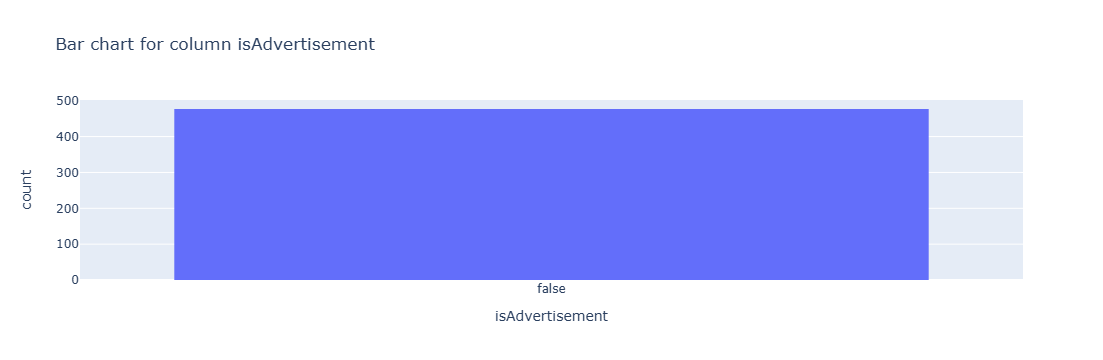

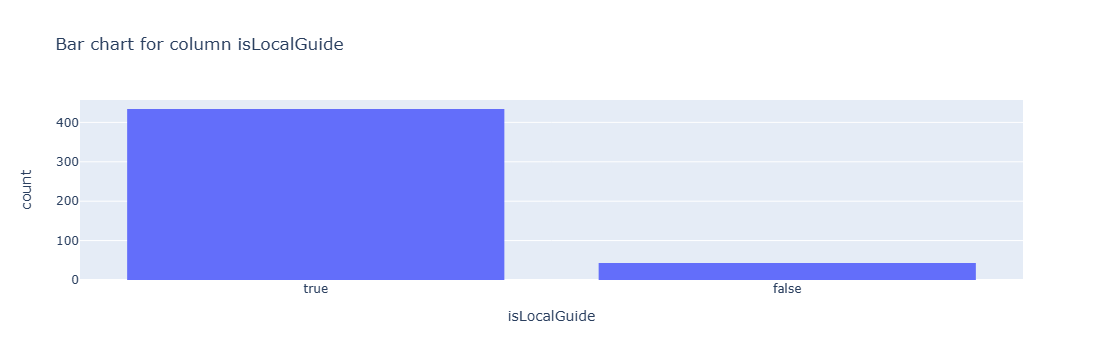

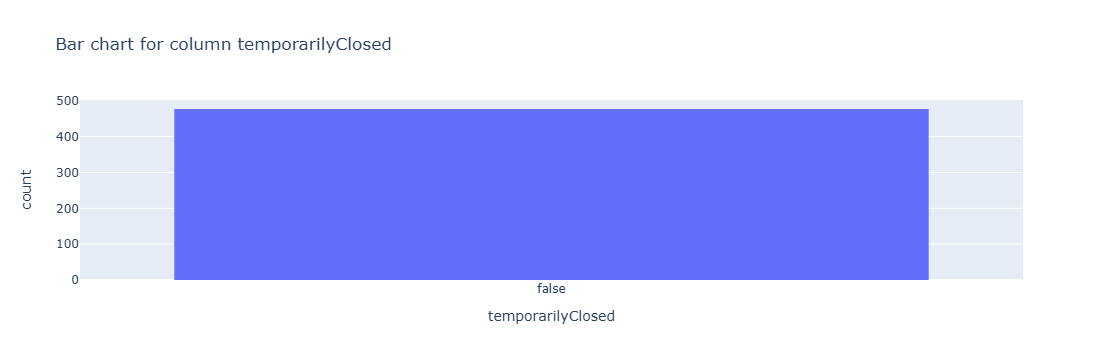

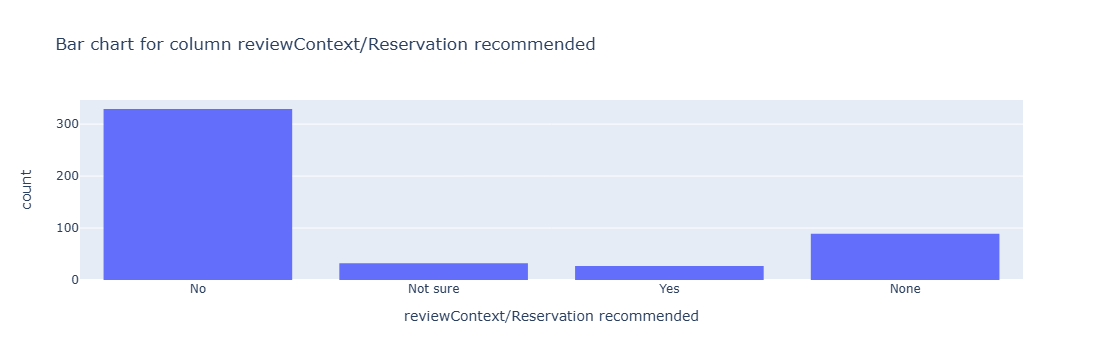

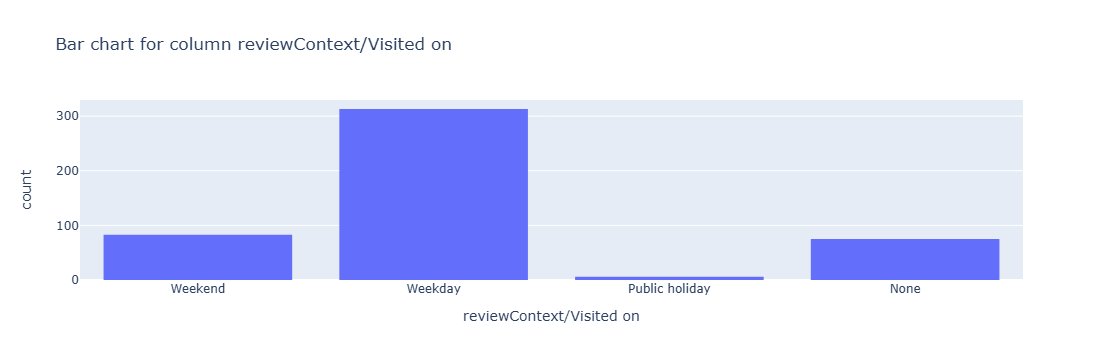

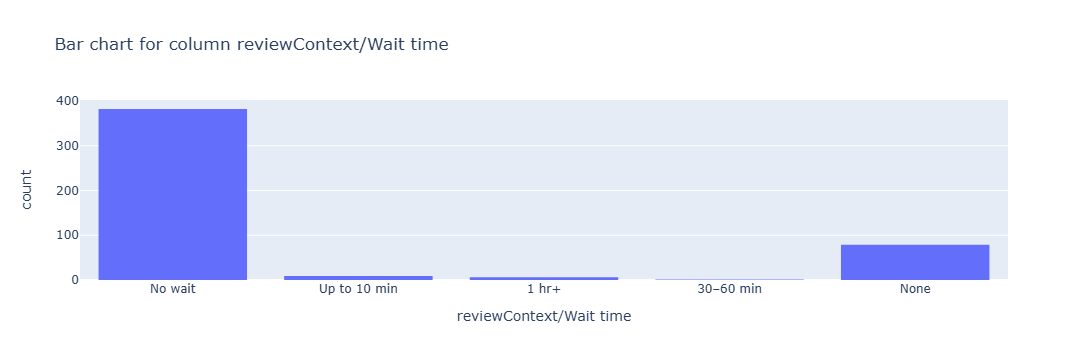

In [45]:
#analyzing categorical data first
for n in ['isAdvertisement','isLocalGuide','temporarilyClosed','reviewContext/Reservation recommended',
       'reviewContext/Visited on', 'reviewContext/Wait time']:
    fig=px.histogram(data_frame=df_filtered,x=n, title=f"Bar chart for column {n}")
    fig.show()
    

## Categorical to categorical univariate analysis 
1. Is advertisement: All of the data from the museums have not been advertized. We will remove this column.
2. Is Local guide: 337 out of 372 of the museums had local guides with them, which makes up for 90.5 percent. Could those that didn't have guides have received negative reviews?
3. Temporarily closed : All false, we will remove this column.
4. Review context reservation recommended: This describes the review based on the tourist being required to reserve the trip or not. 85 percent of the reviews didn't need to reserve, and 8 percent were unsure, leaving only 6 percent who needed to reserve. Do the sentiments and text cloud words differ based on this?
5. Review context viewed on: This specifies the days the tourist visited the museum, 78 percent visited on the weekdays, 24 on the weekend and the rest on public holidays. Analyze this to sentiment classes?
6. Review context wait time: This specifies the review based on how long the tourist had to wait to begin the tour. 357 records didn't need to wait. Is this column related to reservation recommended column? Also did those who waited leave negative reviews?

We can also analyze the texts to identify if the tourist was alone or with others and compare with these columns in relation to the sentiment.

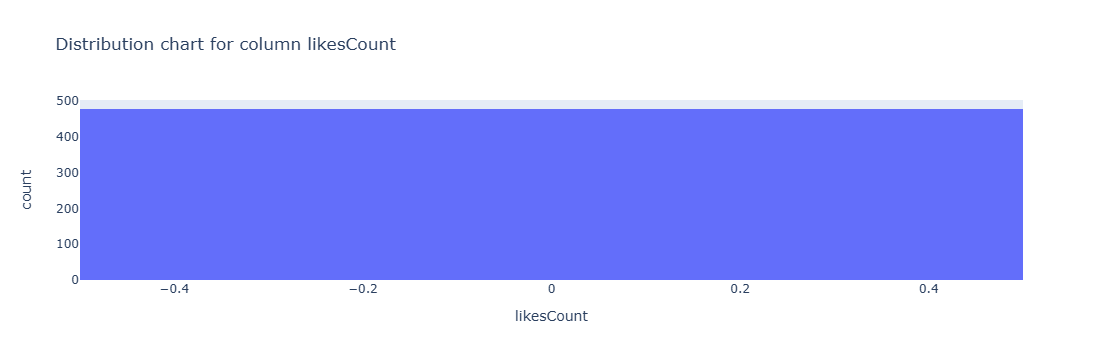

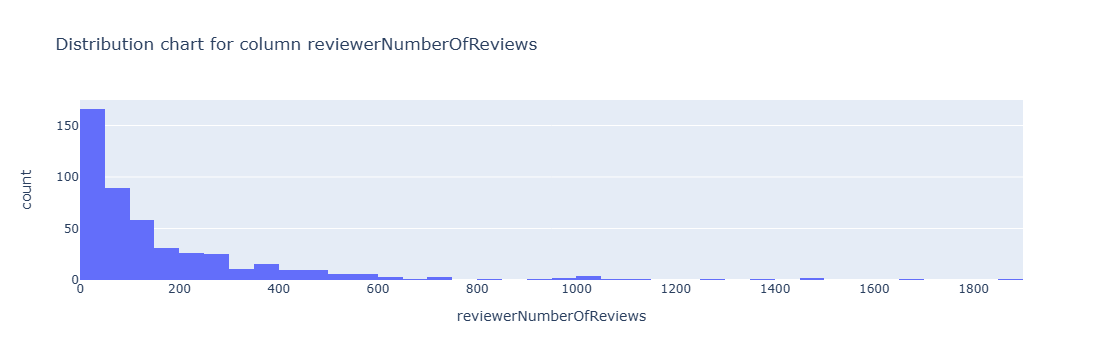

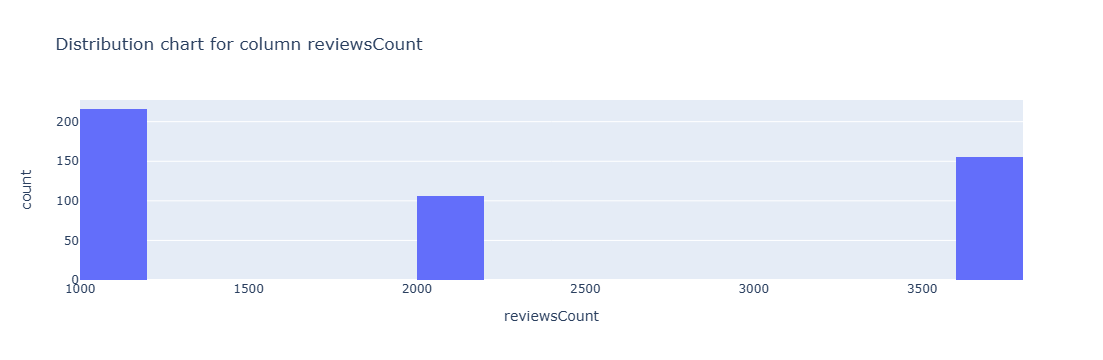

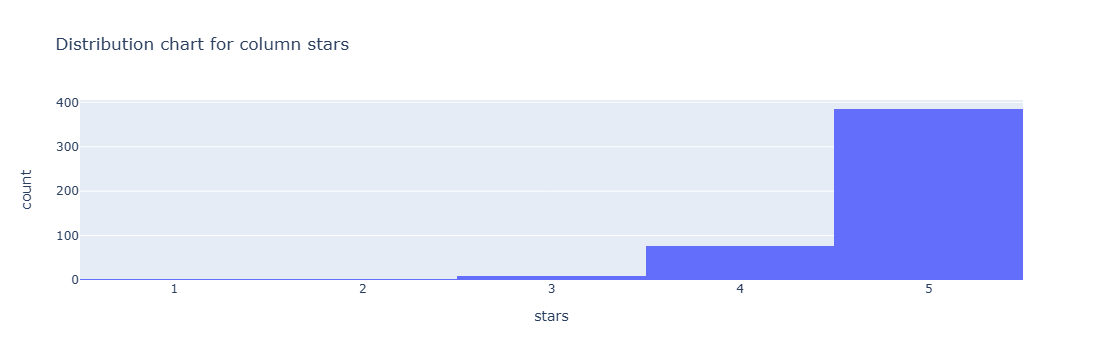

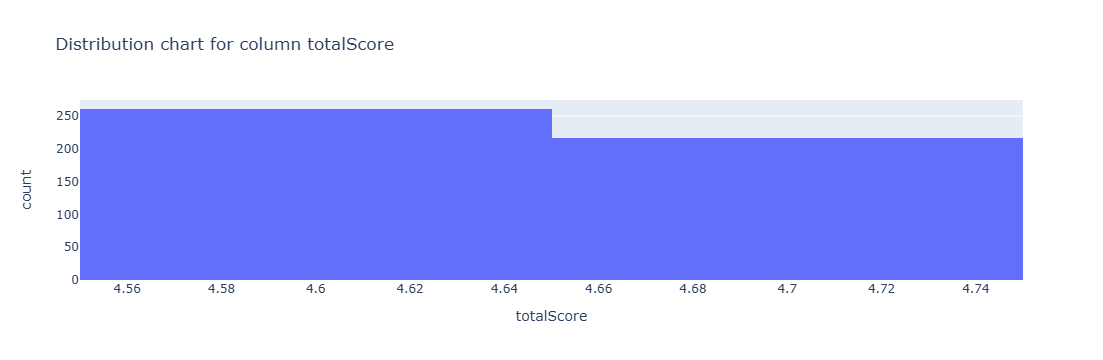

In [46]:
for i in df.select_dtypes([int,float]).columns:
    fig=px.histogram(data_frame=df_filtered,x=i, title=f"Distribution chart for column {i}")
    fig.show()



In [47]:
df.select_dtypes(["int","float"]).describe()

,likesCount,reviewerNumberOfReviews,reviewsCount,stars,totalScore
count,477.0,477.000000,477.000000,477.000000,477.000000
mean,0.0,177.104822,2179.400419,4.761006,4.645283
std,0.0,247.266989,1103.674210,0.559026,0.049829
min,0.0,0.000000,1072.000000,1.000000,4.600000
25%,0.0,30.000000,1196.000000,5.000000,4.600000
50%,0.0,89.000000,2118.000000,5.000000,4.600000
75%,0.0,233.000000,3672.000000,5.000000,4.700000
max,0.0,1856.000000,3672.000000,5.000000,4.700000


## Numeric to numeric analysis

1. Likes count: We will remove it.
2. Reviewers number of reviews: This is the number of reviews the review got. The column is righly skewed, with an median of 83, min of 0 and max of 1856. We can create a column called reviewers_review_number_class and create groups, then identify what makesup these different variations and how they relate to the sentiment?
4. Reviews count: Number of total reviews for each museum.
5. Stars: This column is leftly skewed, with an average of 5, minimum of 1 and max of 5.
6. Total score: Is the overal rating of the experience, the column is mostly uniform with an average of 4.65, with a max of 4.7 and a min of 4.6. There isn't much variation in this one, so we will drop it.

In [48]:
df.drop(["likesCount","totalScore","isAdvertisement","temporarilyClosed"],axis=1,inplace=True)
df_filtered.drop(["likesCount","totalScore","isAdvertisement","temporarilyClosed"],axis=1,inplace=True)

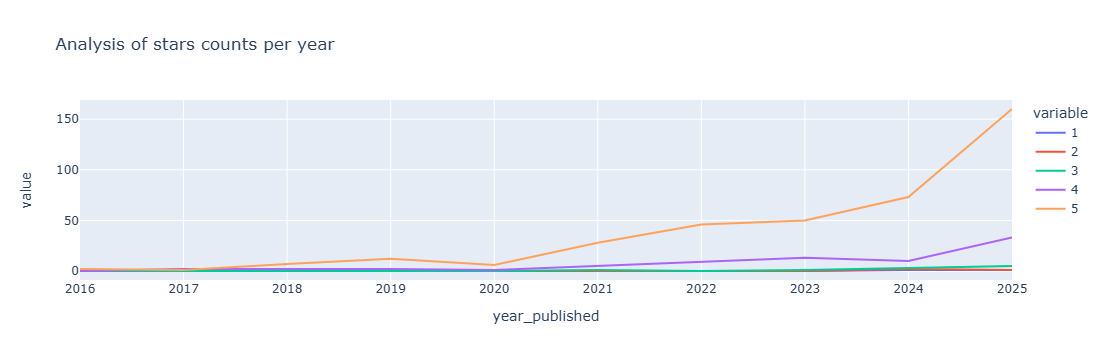

In [120]:
df["year_published"]=df['publishedAtDate'].apply(lambda x: x.split("-")[0])
grouped_stars=pd.crosstab(index=df["year_published"],columns=df["stars"]).reset_index()
fig4=px.line(grouped_stars,x="year_published",y=[1,2,3,4,5],title="Analysis of stars counts per year")
fig4.show()


In [142]:
before_2021=df.loc[(df["year_published"]=="2020")|(df["year_published"]=="2019") | (df["year_published"]=="2018") | (df["year_published"]=="2017") | (df["year_published"]=="2016")]

In [147]:
after_2021=df.loc[(df["year_published"]=="2021")]

In [154]:
after_2021['reviewContext/Wait time'].value_counts()

reviewContext/Wait time
No wait    22
None       12
Name: count, dtype: int64

In [143]:
before_2021.columns

Index(['categories/0', 'categories/1', 'categories/2', 'categories/3',
       'categoryName', 'isLocalGuide', 'language', 'publishAt',
       'publishedAtDate', 'reviewContext/Reservation recommended',
       'reviewContext/Visited on', 'reviewContext/Wait time',
       'reviewerNumberOfReviews', 'reviewsCount', 'stars', 'state', 'text',
       'title', 'categories/4', 'responseFromOwnerDate',
       'responseFromOwnerText', 'categories/5', 'categories/6', 'categories/7',
       'categories/8', 'categories/9', 'sentiment', 'year_published',
       'review_text_count', 'cleaned_text', 'num_reviews_class'],
      dtype='object')

In [153]:
before_2021['reviewContext/Wait time'].value_counts()

reviewContext/Wait time
No wait    20
None       15
Name: count, dtype: int64

Four and five star reviews have grown from 2020 till date. Why is that so? Also which museums are contributing towards this growth?

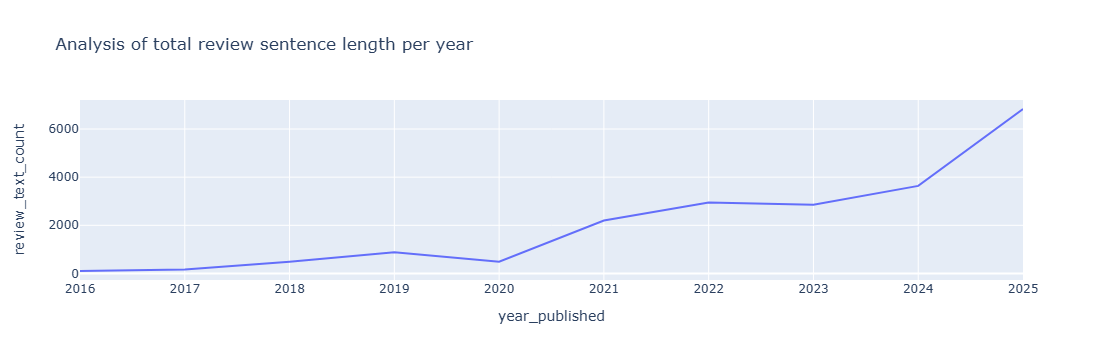

In [51]:
df["review_text_count"]=df["text"].apply(lambda x: len(x.split(" ")))
grouped_text_len=df.groupby("year_published")["review_text_count"].sum().reset_index()
fig5=px.line(grouped_text_len,x="year_published",y="review_text_count",title="Analysis of total review sentence length per year")
fig5.show()


The length of reviews left has also increased as well from 2020 going onwards.

## Text preprocessing

## Topic modelling

In [77]:
#removing emails, urls and tags in dataset
def clean_text(text):
    # 1. Remove URLs (http/https and standalone www/ftp)
    # This is a general pattern and may not catch every single edge case, but is robust for most common URLs.
    url_pattern = r'https?://\S+|www\.\S+|\S+\.\S+/\S+|\ftp\.\S+'
    text = re.sub(url_pattern, '', text)
    
    # 2. Remove Email Addresses
    # A simple but effective pattern for common email formats (user@domain.tld)
    email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
    text = re.sub(email_pattern, '', text)
    
    # 3. Remove Tags (Hashtags and Mentions)
    # Hashtags start with #, Mentions start with @, followed by word characters
    tag_pattern = r'[#@]\w+'
    text = re.sub(tag_pattern, '', text)
    
    # 4. Optional: Clean up extra spaces resulting from the removals
    text = re.sub(r'\s+', ' ', text).strip()
    text=text.lower()
    text= re.sub(r'[^\w\s]', '', text)
    cleaned_sentence_list=[]
    # 5. Tokenizing
    text=nltk.sent_tokenize(text)
    lemma=WordNetLemmatizer()
    for n in range(len(text)):
        words=nltk.word_tokenize(text[n])
       
        words=[lemma.lemmatize(word) for word in words if word not in set(stopwords.words("english"))]
        cleaned_sentence_list=" ".join(words)    
        
    
    
    return cleaned_sentence_list

#tokenizing function
def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))

#word cloud function
def word_cloud(topic_dict,n):
        stopwords_set=set(stopwords.words("english"))
        stopwords_set.add("darwin")
        wordcloud = WordCloud(
                width=800,
                height=400,
                background_color='white',
                max_words=100,
                stopwords=stopwords_set
            ).generate_from_frequencies(topic_dict)
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis("off")
        plt.title(f"Word cloud for topic {n}")
        plt.show()




In [78]:
#pip install gensim
#install if you haven't
import gensim
from gensim.utils import simple_preprocess
import gensim.corpora as corpora
from gsdmm import MovieGroupProcess

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1)]
In stage 0: transferred 0 clusters with 1 clusters populated
In stage 1: transferred 0 clusters with 1 clusters populated
In stage 2: transferred 0 clusters with 1 clusters populated
In stage 3: transferred 0 clusters with 1 clusters populated
In stage 4: transferred 0 clusters with 1 clusters populated
In stage 5: transferred 0 clusters with 1 clusters populated
In stage 6: transferred 0 clusters with 1 clusters populated
In stage 7: transferred 0 clusters with 1 clusters populated
In stage 8: transferred 0 clusters with 1 clusters populated
In stage 9: transferred 0 clusters with 1 clusters populated
In stage 10: transferred 0 clusters with 1 clusters populated
In stage 11: transferred 0 clusters with 1 clusters populated
In stage 12: transferred 0 clusters with 1 cluster

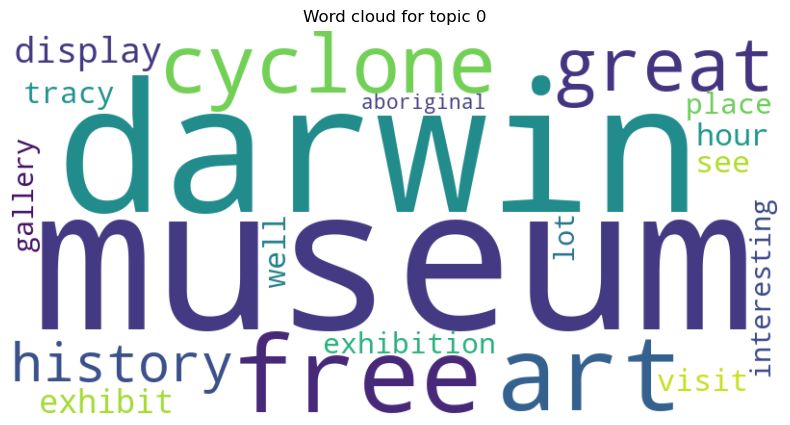

In [79]:
for index,row in df.iterrows():
    df.loc[index, "cleaned_text"] = clean_text(row["text"])
df["cleaned_text"]=df["cleaned_text"].apply(lambda x: x.strip()) 

data = df["cleaned_text"].values.tolist()
data_words = list(sent_to_words(data))

# Create Dictionary
id2word = corpora.Dictionary(data_words)

# Create Corpus
texts = data_words

# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]

# View
print(corpus[:1][0][:30])

#RUNNING MODEL 
vocab_length=len(id2word)
# K refers to the number of clusters you need, for this case, since they are all museums, I made them one
#So when we combine our datasets adn run through the model, we will set K to the 4
#N_iters is the number of times the model will run to converging.
#Alpha makes the model consolidate words into existing large clusters, hence preventing the creation of unncessary small clusters
#Beta This encourages words to be assigned to a topic based on how frequently they already appear in that specific topic
K=1
gsdmm = MovieGroupProcess(K=K, alpha=0.1, beta=0.1, n_iters=30)
# fit GSDMM model
y = gsdmm.fit(data_words, vocab_length)

#Sort topic in preparation for wordcloud
word_dist=gsdmm.cluster_word_distribution
# Select topic you want to output as dictionary
topic_dict_gsdmm= sorted(word_dist[0].items(), key=lambda k: k[1], reverse=True)[:20]
topic_dict_gsdmm=dict(topic_dict_gsdmm)

#print wordclouds
for n in range(0,1):
    word_cloud(topic_dict_gsdmm,n)

In [82]:
import numpy as np

In [90]:
##Analyzing which type of reviews had the highest reviews counts
bins=np.linspace(df['reviewerNumberOfReviews'].min(),df['reviewerNumberOfReviews'].max(),num=4)
labels=["Low","Medium","High"]
df["num_reviews_class"]=pd.cut(df['reviewerNumberOfReviews'],bins=bins,labels=labels,include_lowest=True)

In [91]:
df["num_reviews_class"].value_counts()

num_reviews_class
Low       454
Medium     17
High        6
Name: count, dtype: int64

In [99]:
df.loc[df["num_reviews_class"]=="Medium"]['sentiment'].value_counts()

sentiment
Positive    17
Name: count, dtype: int64

In [101]:
df.loc[df["num_reviews_class"]=="High"]['sentiment'].value_counts()

sentiment
Positive    6
Name: count, dtype: int64

In [100]:
df.loc[df["num_reviews_class"]=="Low"]['sentiment'].value_counts()

sentiment
Positive    428
Negative     16
Neutral      10
Name: count, dtype: int64

In [109]:
df.loc[df["sentiment"]=="Positive"]['title'].value_counts()

title
Museum and Art Gallery of the Northern Territory    145
Darwin Aviation Museum                              110
Darwin Military Museum                              100
RFDS Darwin Tourist Facility                         96
Name: count, dtype: int64

We see that reviews that are under Medium to High in the num_review_class, are all positive sentiments, and under Low, the sentiment classes vary.

The RFDS, Art and Galler; and Military museum are the museums with reviews under the High class. We also see that Museum and Art Gallery of the Northern Territory has the highest number of positive sentiments, followed by thr Aviation and Military museums with just a unit of 10 difference.


In [113]:
#despite RFDS Darwin Tourist Facility having responses from the owner, they still have the least positive sentiments
df.loc[df['responseFromOwnerText'] !='None']["title"].value_counts()

title
RFDS Darwin Tourist Facility    99
Name: count, dtype: int64

In [118]:
df.columns

Index(['categories/0', 'categories/1', 'categories/2', 'categories/3',
       'categoryName', 'isLocalGuide', 'language', 'publishAt',
       'publishedAtDate', 'reviewContext/Reservation recommended',
       'reviewContext/Visited on', 'reviewContext/Wait time',
       'reviewerNumberOfReviews', 'reviewsCount', 'stars', 'state', 'text',
       'title', 'categories/4', 'responseFromOwnerDate',
       'responseFromOwnerText', 'categories/5', 'categories/6', 'categories/7',
       'categories/8', 'categories/9', 'sentiment', 'year_published',
       'review_text_count', 'cleaned_text', 'num_reviews_class'],
      dtype='object')

## Bivariate analysis

Categorical to categorical

1. Could those that didn't have guides have received negative reviews?
2. Review context reservation recommended: This describes the review based on the tourist being required to reserve the trip or not. 85 percent of the reviews didn't need to reserve, and 8 percent were unsure, leaving only 6 percent who needed to reserve. Do the sentiments and text cloud words differ based on this?
3. Review context viewed on: This specifies the days the tourist visited the museum, 78 percent visited on the weekdays, 24 on the weekend and the rest on public holidays. Analyze this to sentiment classes?
4. Review context wait time: This specifies the review based on how long the tourist had to wait to begin the tour. 357 records didn't need to wait. Is this column related to reservation recommended column? Also did those who waited leave negative reviews?
5. Analyze the texts to identify if the tourist was alone or with others and compare with these columns in relation to the sentiment.

Numeric to numeric

1. We can create a column called reviewers_review_number_class and create groups, then identify what makesup these different variations and how they relate to the sentiment?
2. Does review number of reviews correlate to stars and reviews count?
3. Does stars correlate to review counts?


## Could those that didn't have guides have received negative reviews?

In [248]:
pd.crosstab(index=df_filtered["isLocalGuide"],columns=df_filtered["sentiment"])

sentiment,Neutral,Strong Negative,Strong Positive,Weak Negative,Weak Positive
isLocalGuide,,,,,
False,4,0,14,0,17
True,7,1,82,12,235


There's no variation, so the answer is no

In [249]:
pd.crosstab(index=df_filtered['reviewContext/Reservation recommended'],columns=df_filtered["sentiment"])

sentiment,Neutral,Strong Negative,Strong Positive,Weak Negative,Weak Positive
reviewContext/Reservation recommended,,,,,
No,9,1,81,9,217
Not sure,1,0,7,2,21
Yes,1,0,8,1,14


In [250]:
#lets analyze the weak positive texts
strings=df_filtered.loc[(df_filtered['reviewContext/Reservation recommended']=="Yes") & (df_filtered["sentiment"]=="Weak Positive")]["text"].values

In [251]:
strings[3]

'Wonderful planes and staff, was just disappointed as we could not go in cockpit. We were advised on our exit that cockpit sitting is only on certain days, please check their website or call to avoid disappointment:) but well worth the trip!'

This is a good insight, the Darwin aviation museum should clearly state the dates when tourist can book to enter the cookpit

In [252]:
def wordcloud_generator(df_filtered,n):
    string_list=df_filtered.loc[df_filtered["sentiment"]==n]["text"].values
    stopwords_set=set(stopwords.words("english"))
    stopwords_set.add("Darwin")
    text=" ".join(string_list)
    wordcloud = WordCloud(
            width=800,
            height=400,
            background_color='white',
            max_words=100,
            stopwords=stopwords_set
        ).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word cloud for {n}")
    plt.show()

In [253]:
#first lets identify which museums pair to which sentiment
pd.crosstab(index=df["title"],columns=df["sentiment"])

sentiment,Neutral,Strong Negative,Strong Positive,Weak Negative,Weak Positive
title,,,,,
Darwin Aviation Museum,3,0,26,4,84
Darwin Military Museum,1,1,18,4,82
Museum and Art Gallery of the Northern Territory,6,0,18,2,24
RFDS Darwin Tourist Facility,1,0,34,2,62


In [254]:
#strong negative review from Darwin aviation
df_filtered.loc[df_filtered["sentiment"]=="Strong Negative"]["text"].values

array(["The story of how Japan invaded Darwin. Some of the stories were such an eye opener.  Horrible to know it's still happening today."],
      dtype=object)

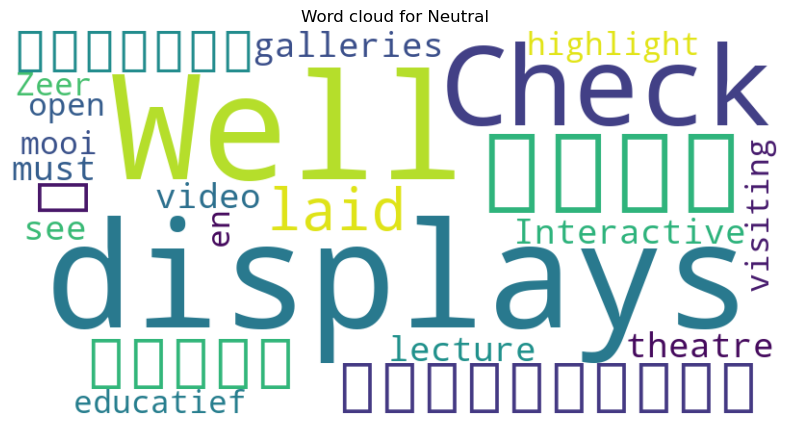

In [255]:
#investigating the museum and art gallery
art_gallery=df.loc[df["title"]=="Museum and Art Gallery of the Northern Territory"]
wordcloud_generator(art_gallery,"Neutral")

In [285]:
art_gallery.loc[art_gallery["sentiment"]=="Neutral"]["text"].values

array(['Check it out when in Darwin!', 'งานศิลปะและประวัติศาสตร์เยอะมาก',
       'Well laid out galleries.   Interactive displays as well as lecture theatre and video displays.',
       'A must see in darwin. Was a highlight of visiting darwin',
       'Zeer educatief en mooi', 'Nor open'], dtype=object)

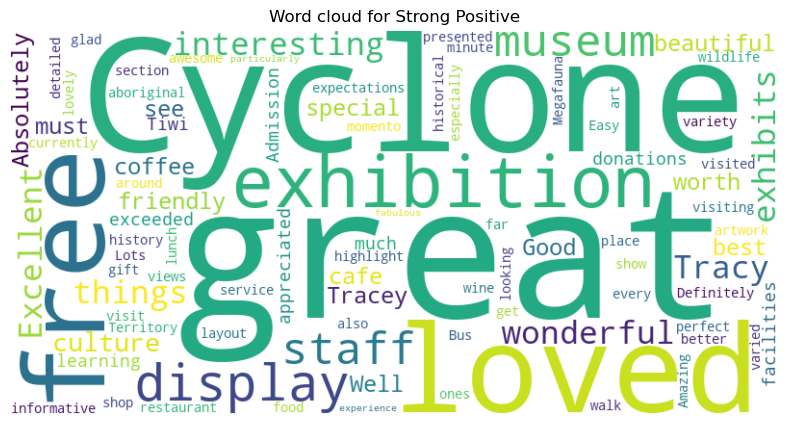

In [288]:
#rfds
rfds=df.loc[df["title"]=='RFDS Darwin Tourist Facility']
wordcloud_generator(art_gallery,"Strong Positive")

The darwin miliatry museum is the only one with a negative review. This was a false negative as it was related towards the history, and not towards the museum.

The Museum and art gallert  has the most neutral reviews. Overal the reviews liked the museum, hence these are fall neutrals.

RFDS has the most strong reviews, what made it stand out compared to the others.

All of them had weak negative reviews, investigate the weak negative reviews.


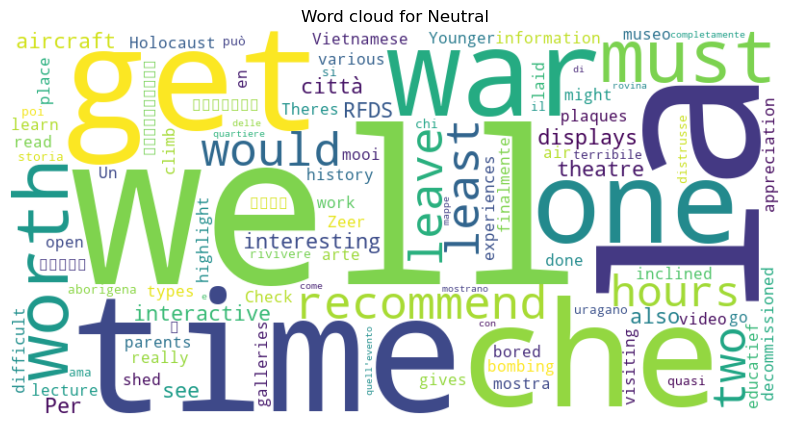

In [209]:
wordcloud_generator(df_filtered,"Neutral")